# Concept 52 – MCP Server and LangGraph MCP Client

This notebook is a teaching demo for MCP (Model Context Protocol):

1. Build a custom MCP server with FastMCP.
2. Expose course-related tools from that server.
3. Connect to the MCP server as an MCP client.
4. Give the MCP tools to a LangGraph ReAct agent.
5. Ask the agent a question and watch it call the MCP server.

**Architecture**
```
User question
    -> LangGraph agent (Claude Haiku)
        -> MCP client adapter (langchain-mcp-adapters)
            -> Custom FastMCP server (course_mcp_server.py)
                -> in-memory course tools
```

> **Before running:** make sure your `.env` file contains `ANTHROPIC_API_KEY`.

## Step 1 – Install Required Packages

Run this cell once. It installs:
- `mcp` – the core MCP library (server + client primitives)
- `langchain-mcp-adapters` – converts MCP tools into LangChain `BaseTool` objects
- `langchain-anthropic` – LangChain wrapper for Claude models

In [1]:
%pip install -q mcp langchain-mcp-adapters langchain-anthropic


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Step 2 – Create the MCP Server

`%%writefile` saves the server code to `course_mcp_server.py` on disk.
The MCP client will launch this file as a **subprocess** and talk to it over `stdio`.

The server exposes:
- **Tools** (`@mcp.tool`) – callable functions the LLM can invoke
- **Resource** (`@mcp.resource`) – read-only data accessible by URI
- **Prompt** (`@mcp.prompt`) – reusable prompt templates

In [2]:
%%writefile course_mcp_server.py
import json
from mcp.server.fastmcp import FastMCP

# FastMCP is a high-level wrapper that turns plain Python functions into MCP tools.
# The string argument is the server name visible in client logs.
mcp = FastMCP("Course Helper MCP Server")

# In-memory course catalog — each key is a unique course ID.
# In a real app this would be a database query.
COURSES = {
    "lg-101": {
        "title": "LangGraph Fundamentals",
        "level": "beginner",
        "duration_weeks": 2,
        "topics": ["state graph", "nodes", "edges", "tool calling"],
    },
    "mcp-101": {
        "title": "Model Context Protocol Basics",
        "level": "beginner",
        "duration_weeks": 1,
        "topics": ["mcp server", "mcp client", "tools", "resources", "prompts"],
    },
    "agent-201": {
        "title": "Agentic AI with LangGraph",
        "level": "intermediate",
        "duration_weeks": 3,
        "topics": ["react agent", "multi-agent", "memory", "human feedback"],
    },
}


# @mcp.tool() registers this function as a callable MCP tool.
# The docstring is what the LLM reads to decide when and how to call this tool.
@mcp.tool()
def search_courses(topic: str) -> list[dict]:
    """Search courses by topic, title, or level."""
    query = topic.lower()
    matches = []
    for course_id, course in COURSES.items():
        # Flatten all fields into one string for simple substring matching
        searchable = " ".join(
            [course_id, course["title"], course["level"], *course["topics"]]
        ).lower()
        if query in searchable:
            matches.append({"course_id": course_id, **course})
    return matches


@mcp.tool()
def get_course_details(course_id: str) -> dict:
    """Get full details for a course by course id."""
    course = COURSES.get(course_id.lower())
    if not course:
        # Structured error so the LLM can recover gracefully instead of crashing
        return {
            "error": f"Course '{course_id}' was not found.",
            "available_course_ids": list(COURSES.keys()),
        }
    return {"course_id": course_id.lower(), **course}


@mcp.tool()
def calculate_learning_time(weeks: int, hours_per_week: int) -> dict:
    """Calculate total learning hours from weeks and hours per week."""
    total_hours = weeks * hours_per_week
    return {
        "weeks": weeks,
        "hours_per_week": hours_per_week,
        "total_hours": total_hours,
    }


# @mcp.resource() exposes read-only data via a URI — NOT a callable tool.
# Think of it like a GET endpoint: the client fetches it, the LLM cannot call it.
@mcp.resource("course://catalog")
def course_catalog() -> str:
    """Return the complete course catalog as JSON."""
    return json.dumps(COURSES, indent=2)


# @mcp.prompt() registers a reusable prompt template.
# Clients fetch and fill in these templates before sending them to an LLM.
@mcp.prompt()
def study_plan_prompt(goal: str, weeks: int) -> str:
    """Create a reusable prompt for generating a study plan."""
    return (
        f"Create a {weeks}-week study plan for this learning goal: {goal}. "
        "Use course recommendations, weekly milestones, and practice tasks."
    )


if __name__ == "__main__":
    # stdio transport: the MCP client spawns this script as a subprocess and
    # communicates with it through stdin/stdout pipes — no network port needed.
    mcp.run(transport="stdio")


Overwriting course_mcp_server.py


## Steps 3–6 — MCP Client → Direct Test → Build Agent → Run Agent\n\nAll four steps run in the single code cell below.\n\n| Section comment | What it covers |\n|---|---|\n| `# ── Step 3` | Create MCP client, discover tools via `get_tools()` |\n| `# ── Step 4` | Call one tool directly (sanity check) |\n| `# ── Step 5` | Build the LangGraph ReAct agent |\n| `# ── Step 6` | Ask the agent a question, print conversation |

/Users/utsabchakraborty/Documents/Edureka_May2026/LangGraph/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tools discovered from MCP server:
  - search_courses: Search courses by topic, title, or level.
  - get_course_details: Get full details for a course by course id.
  - calculate_learning_time: Calculate total learning hours from weeks and hours per week.

Direct search_courses('mcp') result:
[{'type': 'text', 'text': '{\n  "course_id": "mcp-101",\n  "title": "Model Context Protocol Basics",\n  "level": "beginner",\n  "duration_weeks": 1,\n  "topics": [\n    "mcp server",\n    "mcp client",\n    "tools",\n    "resources",\n    "prompts"\n  ]\n}', 'id': 'lc_f1755900-9a0c-4118-a059-46b75b11e51a'}]


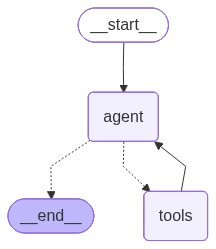


─── Agent Conversation ─────────────────────────────────────
================================ Human Message =================================

I am a beginner and want to learn MCP with LangGraph. Find relevant courses and estimate my total learning time if I study 6 hours per week for 4 weeks.
================================== Ai Message ==================================

[{'text': "I'll help you find relevant courses on MCP with LangGraph and calculate your learning time commitment.", 'type': 'text'}, {'id': 'toolu_01E6Aseks39zPgZVuWMxJLfT', 'caller': {'type': 'direct'}, 'input': {'topic': 'MCP LangGraph'}, 'name': 'search_courses', 'type': 'tool_use'}, {'id': 'toolu_01ByMF7qxsgAMzS2tH9DV68c', 'caller': {'type': 'direct'}, 'input': {'weeks': 4, 'hours_per_week': 6}, 'name': 'calculate_learning_time', 'type': 'tool_use'}]
Tool Calls:
  search_courses (toolu_01E6Aseks39zPgZVuWMxJLfT)
 Call ID: toolu_01E6Aseks39zPgZVuWMxJLfT
  Args:
    topic: MCP LangGraph
  calculate_learning_time 

In [3]:
import sys
from pathlib import Path

from dotenv import load_dotenv
from langchain_anthropic import ChatAnthropic
from langchain_mcp_adapters.client import MultiServerMCPClient
from langgraph.graph import START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

# Load all keys from .env — override=True refreshes stale values in the kernel.
# This picks up ANTHROPIC_API_KEY so ChatAnthropic works without extra config.
load_dotenv(override=True)

# Absolute path to the server script written by %%writefile in Step 2
SERVER_PATH = Path("course_mcp_server.py").resolve()

# ── Step 3: MCP Client ────────────────────────────────────────────────────────
# In langchain-mcp-adapters >= 0.1.0 the async context manager was removed.
# The correct pattern is: create the client, then call get_tools().
# get_tools() launches the MCP server subprocess, opens the stdio session,
# and converts each MCP tool schema into a LangChain BaseTool object.
# Keep mcp_client in scope — it holds the live server connection.
mcp_client = MultiServerMCPClient(
    {
        "course_server": {
            "command": sys.executable,   # same Python interpreter as this notebook
            "args": [str(SERVER_PATH)],  # the FastMCP server script from Step 2
            "transport": "stdio",        # communicate via stdin/stdout pipes
        }
    }
)

mcp_tools = await mcp_client.get_tools()

print("Tools discovered from MCP server:")
for tool in mcp_tools:
    print(f"  - {tool.name}: {tool.description}")

# ── Step 4: Direct Tool Test ──────────────────────────────────────────────────
# Call one MCP tool directly before involving the agent.
# This proves the server is alive and the session is working.
# It also shows that MCP tools are just callable objects — no agent needed.
search_tool = next(t for t in mcp_tools if "search_courses" in t.name)
direct_result = await search_tool.ainvoke({"topic": "mcp"})
print("\nDirect search_courses('mcp') result:")
print(direct_result)

# ── Step 5: Build LangGraph Agent ─────────────────────────────────────────────
# Claude Haiku — fast, inexpensive, supports tool calling.
# ANTHROPIC_API_KEY is read automatically from the environment loaded above.
llm = ChatAnthropic(model="claude-haiku-4-5-20251001", temperature=0)

# bind_tools() injects the MCP tool schemas into every LLM call so the model
# knows the tool names, descriptions, and argument types.
llm_with_mcp_tools = llm.bind_tools(mcp_tools)

async def call_model(state: MessagesState):
    # Send the full message history to the LLM.
    # The response is an AIMessage — either with tool_calls or a final answer.
    response = await llm_with_mcp_tools.ainvoke(state["messages"])
    return {"messages": [response]}

# Build the graph: START → agent ⇄ tools → END
builder = StateGraph(MessagesState)
builder.add_node("agent", call_model)

# ToolNode reads tool_calls from the last AIMessage, executes each MCP tool,
# and appends the results as ToolMessages into the state.
builder.add_node("tools", ToolNode(mcp_tools))

builder.add_edge(START, "agent")

# tools_condition: if the last AIMessage has tool_calls → route to "tools"
#                  if the last AIMessage is a plain text reply → route to END
builder.add_conditional_edges("agent", tools_condition)

# After tools run, send results back to the agent for the final answer
builder.add_edge("tools", "agent")

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

# ── Step 6: Run the Agent ──────────────────────────────────────────────────────
question = (
    "I am a beginner and want to learn MCP with LangGraph. "
    "Find relevant courses and estimate my total learning time if I study "
    "6 hours per week for 4 weeks."
)

# ainvoke() drives the full ReAct loop until the agent produces a final answer:
#   Turn 1 — agent node : LLM sees the question, decides to call tools
#   Turn 2 — tools node : ToolNode calls search_courses + calculate_learning_time
#                         via the MCP client; results come back as ToolMessages
#   Turn 3 — agent node : LLM reads tool results, writes the final answer
response = await graph.ainvoke({"messages": [("user", question)]})

# pretty_print() labels each message type in the full conversation:
#   HumanMessage → the original question
#   AIMessage    → LLM response (may contain tool_calls on the first pass)
#   ToolMessage  → raw result returned by each MCP tool
#   AIMessage    → the final natural-language answer
print("\n─── Agent Conversation ─────────────────────────────────────")
for message in response["messages"]:
    message.pretty_print()


# Step 7 — Teaching Notes

---

# What is MCP and why does it matter?

**MCP (Model Context Protocol)** is an open standard that separates:

- **Tool implementation**
- **Agent logic**

Before MCP, every tool had to be written directly inside the agent codebase as Python functions.

With MCP:

- Tools live in an independent **server process**
- The agent only needs:
  - tool name
  - description
  - argument schema

This means:

✅ The same MCP server can be reused by multiple agents  
✅ Works across different languages and frameworks  
✅ Tools become modular and reusable  
✅ Agent logic stays clean and lightweight

---

# Key Concepts Explained

---

## `@mcp.tool()` — Registering a Tool

Decorating a Python function with `@mcp.tool()` exposes it as an MCP tool.

```python
@mcp.tool()
def get_weather(city: str) -> str:
    """Get current weather for a city."""
```

### Important

The function **docstring** becomes the tool description shown to the LLM.

The LLM uses this description to decide:

- when to use the tool
- how to use the tool
- what arguments to pass

So good docstrings are extremely important.

---

## `@mcp.resource()` — Read-Only Data

Resources are **not callable tools**.

They behave more like REST `GET` endpoints and are accessed via URI.

Example use cases:

- documentation
- configs
- catalogs
- static reference data

### Important

The LLM cannot directly invoke resources.

A client must explicitly fetch them.

---

## `@mcp.prompt()` — Reusable Prompt Templates

Prompts allow reusable prompt engineering inside the MCP server.

Example:

```python
@mcp.prompt()
def summarize_prompt(topic: str):
    return f"Summarize the topic: {topic}"
```

Benefits:

- centralized prompt management
- version-controlled prompts
- reusable across applications

---

## `transport="stdio"` — Client ↔ Server Communication

With `stdio` transport:

- the MCP client launches the server as a subprocess
- communication happens through:
  - `stdin`
  - `stdout`

No HTTP server or ports are needed.

### Ideal for

- local development
- demos
- classroom learning

### Production alternative

Use:

```python
transport="streamable_http"
```

and run the MCP server separately.

---

## `MultiServerMCPClient` — Tool Discovery

The MCP client handles:

- launching the subprocess
- MCP handshake
- schema translation
- tool discovery

Example:

```python
client = MultiServerMCPClient(...)
tools = await client.get_tools()
```

The returned tools are standard LangChain `BaseTool` objects.

At this point:

> LangGraph no longer knows these tools came from MCP.

They behave like normal tools.

---

## Version Note

For:

```text
langchain-mcp-adapters >= 0.1.0
```

the `async with` pattern was removed.

### Correct pattern

```python
client = MultiServerMCPClient(...)
tools = await client.get_tools()
```

---

## `bind_tools()` — Teaching the LLM About Tools

```python
llm.bind_tools(mcp_tools)
```

This injects tool schemas into every LLM request.

The LLM now knows:

- tool names
- descriptions
- argument types

and can autonomously generate tool calls.

---

## `ToolNode` — Executing Tool Calls

`ToolNode` is a prebuilt LangGraph node that:

1. Reads `tool_calls` from the latest `AIMessage`
2. Executes the tools
3. Appends results as `ToolMessage`

It automatically handles:

- async execution
- parallel calls
- error handling

---

## `tools_condition` — Routing Logic

This is a prebuilt conditional edge function.

Logic:

- If message contains `tool_calls`
  → route to `"tools"`

- Otherwise
  → route to `END`

This creates the ReAct loop:

```text
agent → tools → agent → tools → ... → END
```

---

# Full End-to-End Flow

```text
1. User sends a question
   ↓
   HumanMessage added to graph state

2. agent node executes
   ↓
   LLM reads:
   - user question
   - available tool schemas

   Returns:
   AIMessage containing tool_calls

3. tools node executes
   ↓
   ToolNode runs each MCP tool call

   MCP client:
   - sends request over stdio
   - server executes Python function
   - result returned back

   Results added as ToolMessages

4. agent node executes again
   ↓
   LLM reads:
   - original question
   - tool outputs

   Returns:
   final AIMessage (no tool_calls)

5. tools_condition runs
   ↓
   No tool_calls found
   → route to END

6. User receives final answer
```

---

# Visual Mental Model

```text
┌──────────┐
│   User   │
└────┬─────┘
     │
     ▼
┌──────────┐
│  Agent   │
│   LLM    │
└────┬─────┘
     │ tool_calls
     ▼
┌──────────┐
│ ToolNode │
└────┬─────┘
     │
     ▼
┌──────────┐
│ MCP      │
│ Client   │
└────┬─────┘
     │ stdio
     ▼
┌──────────┐
│ MCP      │
│ Server   │
└────┬─────┘
     │
     ▼
┌──────────┐
│ Python   │
│ Function │
└──────────┘
```

---

# Classroom Extension Ideas

| Idea | What to Change |
|---|---|
| Add a new tool | Add `@mcp.tool()` in `course_mcp_server.py` and rerun setup |
| Use a different topic | Change the `question` string |
| Use a stronger model | Replace `claude-haiku-4-5-20251001` with `claude-sonnet-4-6` |
| Switch to HTTP transport | Replace `stdio` with `streamable_http` |
| Use a real MCP server | Replace local server with Filesystem / Git / Fetch / Time MCP servers |
| Add memory | Store previous interactions in graph state |
| Add multiple agents | Use supervisor + worker architecture |
| Add human approval | Insert interrupt node before tool execution |
| Add guardrails | Validate tool inputs and outputs |
| Add observability | Use LangSmith tracing and evaluation |

---

# Important Takeaway

MCP does **not replace LangGraph**.

Instead:

- MCP standardizes **tool access**
- LangGraph orchestrates **reasoning workflows**

Together they create:

✅ Modular agents  
✅ Reusable tools  
✅ Cleaner architecture  
✅ Cross-language interoperability  
✅ Easier scaling in production